In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# tumour dataset
!gdown --fuzzy "https://drive.google.com/file/d/1U-gWcm3gOjsyUeH6c2yQXcsfiZJZPAJS/view?usp=sharing"
!unzip -q "/content/2D-dataset.zip" -d "/content/brain_tumor_dataset"

Mounted at /content/drive
Downloading...
From (original): https://drive.google.com/uc?id=1U-gWcm3gOjsyUeH6c2yQXcsfiZJZPAJS
From (redirected): https://drive.google.com/uc?id=1U-gWcm3gOjsyUeH6c2yQXcsfiZJZPAJS&confirm=t&uuid=c9c35a34-332e-4cdd-92ff-4f85fe4f31d2
To: /content/2D-dataset.zip
100% 165M/165M [00:04<00:00, 36.5MB/s]
100% 165M/165M [00:04<00:00, 36.5MB/s]


In [ ]:
# =========================
# Config
# =========================
DATASET_ROOT_OVERRIDE = None
DRIVE_FILE_LINK = "https://drive.google.com/file/d/1Ox7sCEqtM7gOM8Y72H1bqHULtWolfTu3/view?usp=sharing"

DOWNLOAD_ROOT = Path("/content/dataset_download")
EXTRACT_ROOT = Path("/content/extracted_datasets")

AUTO_DOWNLOAD = True
AUTO_EXTRACT = True

MOUNT_MYDRIVE_FOR_OUTPUTS = True
FORCE_REMOUNT_MYDRIVE = False

import tarfile
import zipfile

IS_COLAB = (
    "COLAB_GPU" in os.environ
    or "COLAB_RELEASE_TAG" in os.environ
    or Path.cwd().as_posix().startswith("/content")
)

if IS_COLAB and MOUNT_MYDRIVE_FOR_OUTPUTS:
    try:
        import importlib
        import subprocess
        import sys
        drive = importlib.import_module("google.colab.drive")
        need_mount = FORCE_REMOUNT_MYDRIVE or (not Path("/content/drive/MyDrive").exists())
        if need_mount:
            print("Mounting Google Drive at /content/drive ...")
            drive.mount("/content/drive", force_remount=FORCE_REMOUNT_MYDRIVE)
        else:
            print("Google Drive already mounted at /content/drive.")
    except Exception as e:
        print(f"Drive mount step skipped or failed: {e}")

def _find_dir_recursively(root: Path, dir_name: str):
    if not root.exists() or not root.is_dir():
        return None
    for p in root.rglob("*"):
        if p.is_dir() and p.name.lower() == dir_name.lower():
            return p
    return None

def _find_any_nifti_parent(root: Path):
    if not root.exists() or not root.is_dir():
        return None
    nii_files = list(root.rglob("*.nii")) + list(root.rglob("*.nii.gz"))
    if not nii_files:
        return None
    return nii_files[0].parent.resolve()

def _pick_downloaded_archive(download_root: Path):
    candidates = []
    for p in download_root.rglob("*"):
        if not p.is_file():
            continue
        name = p.name.lower()
        if name.endswith(".zip") or name.endswith(".tar") or name.endswith(".tar.gz") or name.endswith(".tgz") or name.endswith(".tar.bz2") or name.endswith(".tbz2") or name.endswith(".tar.xz") or name.endswith(".txz"):
            candidates.append(p)
    if not candidates:
        return None
    candidates = sorted(candidates, key=lambda p: p.stat().st_mtime, reverse=True)
    return candidates[0]

def _extract_archive(archive_path: Path, extract_root: Path):
    if not AUTO_EXTRACT:
        raise FileNotFoundError(f"Auto extract disabled, but need extraction for: {archive_path}")
    extract_root.mkdir(parents=True, exist_ok=True)
    name = archive_path.name.lower()
    print(f"Extracting archive: {archive_path}")
    if name.endswith(".zip"):
        with zipfile.ZipFile(archive_path, "r") as zf:
            zf.extractall(extract_root)
        return
    if (
        name.endswith(".tar")
        or name.endswith(".tar.gz")
        or name.endswith(".tgz")
        or name.endswith(".tar.bz2")
        or name.endswith(".tbz2")
        or name.endswith(".tar.xz")
        or name.endswith(".txz")
    ):
        with tarfile.open(archive_path, "r:*") as tf:
            tf.extractall(extract_root)
        return

    raise ValueError(f"Unsupported archive format: {archive_path}")

def _discover_dataset_root() -> Path:
    if DATASET_ROOT_OVERRIDE is not None:
        override = Path(DATASET_ROOT_OVERRIDE).expanduser()
        if not override.exists():
            raise FileNotFoundError(f"DATASET_ROOT_OVERRIDE does not exist: {override}")
        return override.resolve()
    DOWNLOAD_ROOT.mkdir(parents=True, exist_ok=True)
    EXTRACT_ROOT.mkdir(parents=True, exist_ok=True)
    if AUTO_DOWNLOAD:
        print("Installing gdown...")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown"], check=True)
        print("Downloading dataset archive with gdown from shared link...")
        print(f"Download target: {DOWNLOAD_ROOT} (runtime disk)")
        subprocess.run([sys.executable, "-m", "gdown", "--fuzzy", DRIVE_FILE_LINK, "-O", f"{DOWNLOAD_ROOT}/"], check=True)
    archive_path = _pick_downloaded_archive(DOWNLOAD_ROOT)
    if archive_path is not None:
        _extract_archive(archive_path, EXTRACT_ROOT)
    else:
        print("No archive file detected in download root; trying direct-folder/direct-file discovery.")
    final_clean = _find_dir_recursively(EXTRACT_ROOT, "final-clean-data")
    if final_clean is not None:
        return final_clean.resolve()
    t1_dir = _find_dir_recursively(EXTRACT_ROOT, "T1")
    if t1_dir is not None and t1_dir.parent.exists():
        return t1_dir.parent.resolve()
    nii_parent = _find_any_nifti_parent(EXTRACT_ROOT)
    if nii_parent is not None:
        return nii_parent
    t1_dir = _find_dir_recursively(DOWNLOAD_ROOT, "T1")
    if t1_dir is not None and t1_dir.parent.exists():
        return t1_dir.parent.resolve()
    nii_parent = _find_any_nifti_parent(DOWNLOAD_ROOT)
    if nii_parent is not None:
        return nii_parent
    raise FileNotFoundError(
        "Could not find dataset root after gdown download/extract. "
        "Expected a folder containing T1 and/or .nii/.nii.gz files."
    )

DATASET_ROOT = _discover_dataset_root()
T1_ROOT = _find_dir_recursively(DATASET_ROOT, "T1")
if T1_ROOT is None:
    has_nii_here = any(DATASET_ROOT.glob("*.nii")) or any(DATASET_ROOT.glob("*.nii.gz"))
    if has_nii_here:
        T1_ROOT = DATASET_ROOT
    else:
        raise FileNotFoundError(f"Could not locate T1 directory or NIfTI files under dataset root: {DATASET_ROOT}")


Data Preprocessing

Folder structure:
```
data/
├── healthy/
│   ├── healthy_001/
│   │   ├── healthy_001_t1.nii
│   │   └── healthy_001_t2.nii
│
├── tumor/
│   ├── tumor_001/
│   │   ├── tumor_001_t1.nii
│   │   └── tumor_001_t2.nii
```



In [ ]:
# =========================
# Build Binary Classification Dataset
# =========================
import os
import random

train_root = "/content/brain_tumor_dataset/Training"
test_root = "/content/brain_tumor_dataset/Testing"


def build_dataset(root_dir):

    dataset = []

    tumor_classes = ["glioma", "meningioma", "pituitary"]

    # Healthy class
    healthy_dir = os.path.join(root_dir, "notumor")

    for file_name in os.listdir(healthy_dir):

        image_path = os.path.join(healthy_dir, file_name)

        dataset.append({
            "image": image_path,
            "label": 0
        })

    # Tumor classes
    for tumor_class in tumor_classes:

        tumor_dir = os.path.join(root_dir, tumor_class)

        for file_name in os.listdir(tumor_dir):

            image_path = os.path.join(tumor_dir, file_name)

            dataset.append({
                "image": image_path,
                "label": 1
            })

    return dataset


train_files = build_dataset(train_root)
test_files = build_dataset(test_root)

random.shuffle(train_files)
random.shuffle(test_files)

print("Train samples:", len(train_files))
print("Test samples :", len(test_files))

print(train_files[0])

Train samples: 5600
Test samples : 1600
{'image': '/content/brain_tumor_dataset/Training/pituitary/Tr-pi_262.jpg', 'label': 1}


In [ ]:
from sklearn.model_selection import train_test_split

tumor_classes = ["glioma", "meningioma", "pituitary"]
healthy_class = "notumor"


def build_binary_dataset(root_dir):
    data = []

    # Healthy / no tumor
    healthy_dir = os.path.join(root_dir, healthy_class)

    for file_name in os.listdir(healthy_dir):
        if file_name.lower().endswith((".jpg", ".jpeg", ".png")):
            data.append({
                "image": os.path.join(healthy_dir, file_name),
                "label": 0,
                "class_name": "notumor"
            })

    # Tumor classes
    for cls in tumor_classes:
        cls_dir = os.path.join(root_dir, cls)

        for file_name in os.listdir(cls_dir):
            if file_name.lower().endswith((".jpg", ".jpeg", ".png")):
                data.append({
                    "image": os.path.join(cls_dir, file_name),
                    "label": 1,
                    "class_name": cls
                })

    return data


full_train_files = build_binary_dataset(train_root)
test_files = build_binary_dataset(test_root)

random.seed(42)
random.shuffle(full_train_files)
random.shuffle(test_files)

labels = [item["label"] for item in full_train_files]

train_files, val_files = train_test_split(
    full_train_files,
    test_size=0.15,
    random_state=42,
    stratify=labels
)

print("Train:", len(train_files))
print("Val:", len(val_files))
print("Test:", len(test_files))

print(train_files[0])

Train: 4760
Val: 840
Test: 1600
{'image': '/content/brain_tumor_dataset/Training/meningioma/Tr-me_594.jpg', 'label': 1, 'class_name': 'meningioma'}


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image


image_size = 224

train_transforms = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

val_test_transforms = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

In [ ]:
class BrainTumorDataset(Dataset):
    def __init__(self, data_list, transform=None):
        self.data_list = data_list
        self.transform = transform

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        item = self.data_list[idx]

        image_path = item["image"]
        label = item["label"]
        class_name = item["class_name"]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return {
            "image": image,
            "label": torch.tensor(label, dtype=torch.long),
            "path": image_path,
            "class_name": class_name
        }


train_ds = BrainTumorDataset(train_files, transform=train_transforms)
val_ds = BrainTumorDataset(val_files, transform=val_test_transforms)
test_ds = BrainTumorDataset(test_files, transform=val_test_transforms)

In [ ]:
batch_size = 32

train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

batch = next(iter(train_loader))

print("Image batch:", batch["image"].shape)
print("Label batch:", batch["label"].shape)
print("Labels:", batch["label"][:10])

Image batch: torch.Size([32, 3, 224, 224])
Label batch: torch.Size([32])
Labels: tensor([1, 0, 0, 0, 1, 0, 0, 1, 1, 1])


3D Classification Model

In [ ]:
import torch.nn as nn
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Replace final layer for binary classification
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

model = model.to(device)

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

Device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 225MB/s]


In [ ]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
from tqdm import tqdm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


def train_one_epoch(model, loader, optimizer, loss_fn, device):
    model.train()

    total_loss = 0
    all_preds = []
    all_labels = []

    for batch in tqdm(loader, desc="Training"):
        images = batch["image"].to(device, non_blocking=True)
        labels = batch["label"].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(images)
        loss = loss_fn(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)

    return avg_loss, acc


def validate_one_epoch(model, loader, loss_fn, device):
    model.eval()

    total_loss = 0
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Validation"):
            images = batch["image"].to(device, non_blocking=True)
            labels = batch["label"].to(device, non_blocking=True)

            outputs = model(images)
            loss = loss_fn(outputs, labels)

            total_loss += loss.item()

            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = torch.argmax(outputs, dim=1)

            all_probs.extend(probs.detach().cpu().numpy())
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / len(loader)

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)

    try:
        auc = roc_auc_score(all_labels, all_probs)
    except:
        auc = 0.0

    return avg_loss, acc, precision, recall, f1, auc

In [ ]:
n_epochs = 20
patience = 5

best_val_f1 = 0
epochs_no_improve = 0

save_path = "/content/best_resnet18_binary_brain_tumor.pth"

train_losses = []
val_losses = []
train_accs = []
val_accs = []
val_f1s = []

for epoch in range(n_epochs):
    print(f"\nEpoch {epoch + 1}/{n_epochs}")

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        optimizer,
        loss_fn,
        device
    )

    val_loss, val_acc, val_precision, val_recall, val_f1, val_auc = validate_one_epoch(
        model,
        val_loader,
        loss_fn,
        device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    val_f1s.append(val_f1)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss  : {val_loss:.4f} | Val Acc  : {val_acc:.4f}")
    print(f"Precision : {val_precision:.4f}")
    print(f"Recall    : {val_recall:.4f}")
    print(f"F1-score  : {val_f1:.4f}")
    print(f"AUC       : {val_auc:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        epochs_no_improve = 0

        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_val_f1": best_val_f1,
            "train_losses": train_losses,
            "val_losses": val_losses,
            "train_accs": train_accs,
            "val_accs": val_accs,
            "val_f1s": val_f1s
        }, save_path)

        print("Saved best model.")
    else:
        epochs_no_improve += 1
        print(f"No improvement: {epochs_no_improve}/{patience}")

    if epochs_no_improve >= patience:
        print("Early stopping triggered.")
        break

print("Best Validation F1:", best_val_f1)


Epoch 1/20


Validation: 100%|██████████| 27/27 [00:01<00:00, 13.74it/s]


Train Loss: 0.0767 | Train Acc: 0.9727
Val Loss  : 0.0351 | Val Acc  : 0.9905
Precision : 0.9921
Recall    : 0.9952
F1-score  : 0.9937
AUC       : 0.9991
Saved best model.

Epoch 2/20


Validation: 100%|██████████| 27/27 [00:01<00:00, 14.11it/s]


Train Loss: 0.0245 | Train Acc: 0.9912
Val Loss  : 0.0306 | Val Acc  : 0.9905
Precision : 0.9921
Recall    : 0.9952
F1-score  : 0.9937
AUC       : 0.9993
No improvement: 1/5

Epoch 3/20


...

Train Loss: 0.0096 | Train Acc: 0.9964
Val Loss  : 0.0558 | Val Acc  : 0.9857
Precision : 0.9889
Recall    : 0.9921
F1-score  : 0.9905
AUC       : 0.9971
No improvement: 3/5

Epoch 11/20


Validation: 100%|██████████| 27/27 [00:01<00:00, 13.67it/s]


Train Loss: 0.0041 | Train Acc: 0.9987
Val Loss  : 0.0451 | Val Acc  : 0.9893
Precision : 0.9921
Recall    : 0.9937
F1-score  : 0.9929
AUC       : 0.9993
No improvement: 4/5

Epoch 12/20


Validation: 100%|██████████| 27/27 [00:01<00:00, 14.12it/s]

Train Loss: 0.0005 | Train Acc: 1.0000
Val Loss  : 0.0401 | Val Acc  : 0.9929
Precision : 0.9952
Recall    : 0.9952
F1-score  : 0.9952
AUC       : 0.9995
No improvement: 5/5
Early stopping triggered.
Best Validation F1: 0.9952380952380953


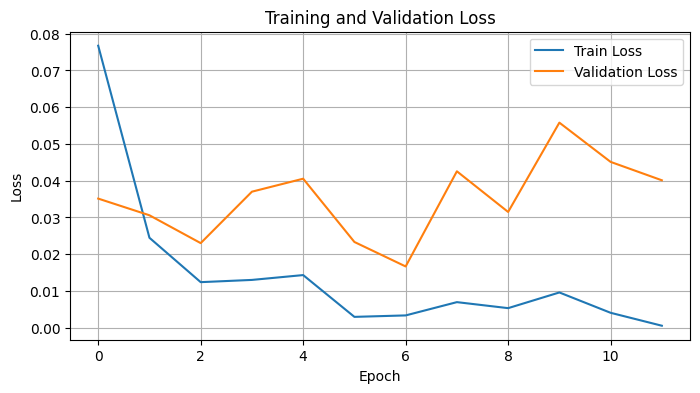

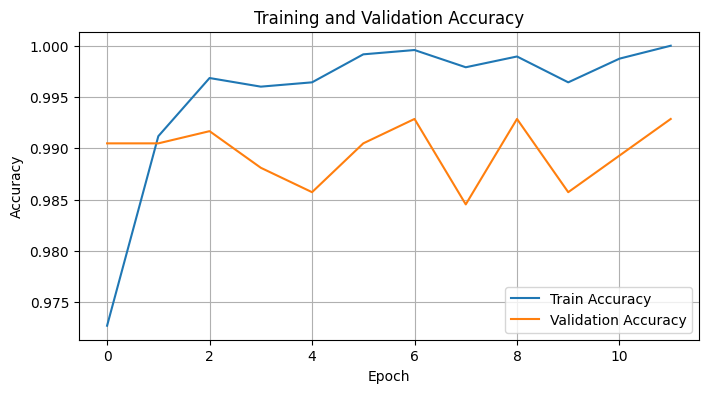

In [ ]:
from matplotlib import pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

Testing: 100%|██████████| 50/50 [00:03<00:00, 14.69it/s]


===== TEST RESULTS =====
Accuracy : 0.9869
Precision: 1.0000
Recall   : 0.9825
F1-score : 0.9912
AUC      : 0.9992

Classification Report:
              precision    recall  f1-score   support

    No Tumor       0.95      1.00      0.97       400
       Tumor       1.00      0.98      0.99      1200

    accuracy                           0.99      1600
   macro avg       0.98      0.99      0.98      1600
weighted avg       0.99      0.99      0.99      1600



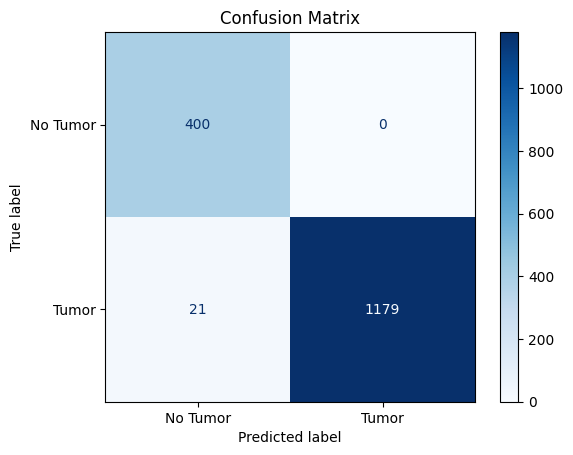

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

checkpoint = torch.load(save_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing"):
        images = batch["image"].to(device, non_blocking=True)
        labels = batch["label"].to(device, non_blocking=True)

        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)[:, 1]
        preds = torch.argmax(outputs, dim=1)

        all_probs.extend(probs.detach().cpu().numpy())
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

test_acc = accuracy_score(all_labels, all_preds)
test_precision = precision_score(all_labels, all_preds, zero_division=0)
test_recall = recall_score(all_labels, all_preds, zero_division=0)
test_f1 = f1_score(all_labels, all_preds, zero_division=0)

try:
    test_auc = roc_auc_score(all_labels, all_probs)
except:
    test_auc = 0.0

print("===== TEST RESULTS =====")
print(f"Accuracy : {test_acc:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1-score : {test_f1:.4f}")
print(f"AUC      : {test_auc:.4f}")

print("\nClassification Report:")
print(classification_report(
    all_labels,
    all_preds,
    target_names=["No Tumor", "Tumor"],
    zero_division=0
))

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Tumor", "Tumor"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()